After running something like this command:
```
./deps/simnibs_4_6/cvenv/bin/python ./petra2density.py me_p2d ./data/me/t1.nii.gz ./data/me/petra_fa1.nii.gz ./results --register_to_petra --fill_holes
```

You will have a `p2d_subject_id/m2m_subject_id` folder with `p2d_density.nii.gz` and other useful files.

Here we look at the estimated density of the skull to see if it is reasonable. Then we compare it to the real CT.

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

In [2]:
p2d_density = nib.load("../results/me_p2d/m2m_me_p2d/p2d_density.nii.gz").get_fdata()
p2d_bone_mask = nib.load("../results/me_p2d/m2m_me_p2d/p2d_bone_mask.nii.gz").get_fdata() == 1
p2d_norm_petra = nib.load("../results/me_p2d/m2m_me_p2d/p2d_norm_petra.nii.gz").get_fdata()

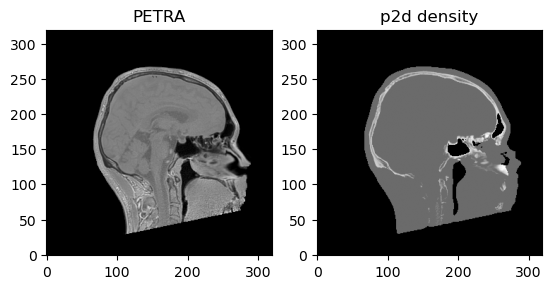

In [3]:
plt.subplot(1, 2, 1)
plt.title("PETRA")
plt.imshow(p2d_norm_petra[160, ...].T, cmap="gray", origin="lower")
plt.subplot(1, 2, 2)
plt.title("p2d density")
plt.imshow(p2d_density[160, ...].T, cmap="gray", origin="lower")
plt.show()

The face and neck sometimes don't look great. I crop them out here to focus on the skull.

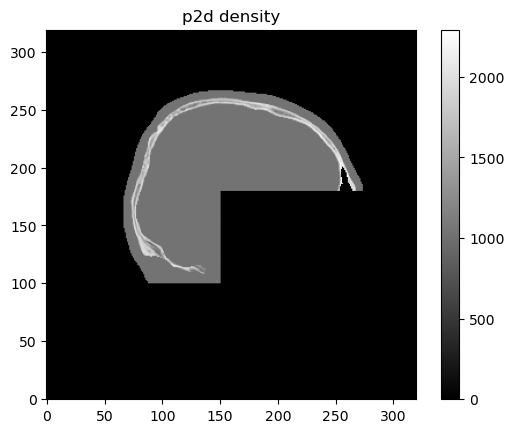

In [4]:
p2d_density_skull = p2d_density.copy()
X, Y, Z = np.meshgrid(*[np.arange(s) for s in p2d_density_skull.shape])
face_neck_sinuses = ((X > 150) & (Z < 180)) | (Z < 100)
p2d_density_skull[face_neck_sinuses] = 0 

plt.title("p2d density")
plt.imshow(p2d_density_skull[160, ...].T, cmap="gray", origin="lower")
plt.colorbar();

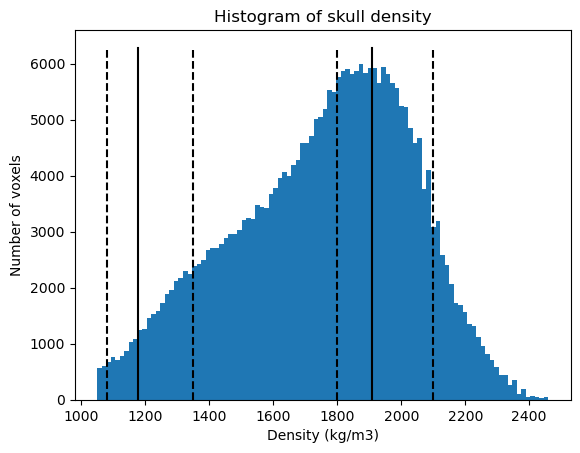

In [5]:
p2d_density_values = p2d_density_skull[(1050 < p2d_density_skull)].flatten()

plt.hist(p2d_density_values, bins=100)

def plot_expected_bone_density(y_range):
    # The average/minimum/maximum density of cortical bone is from:
    # https://itis.swiss/virtual-population/tissue-properties/database/density
    plt.plot([1800, 1800], y_range, '--k')
    plt.plot([1908, 1908], y_range, '-k')
    plt.plot([2100, 2100], y_range, '--k')
    
    # The average/minimum/maximum density of cancellous bone is from:
    # https://itis.swiss/virtual-population/tissue-properties/database/density
    plt.plot([1080, 1080], y_range, '--k')
    plt.plot([1178, 1178], y_range, '-k')
    plt.plot([1350, 1350], y_range, '--k')

plot_expected_bone_density(plt.ylim())
plt.title('Histogram of skull density')
plt.xlabel('Density (kg/m3)')
plt.ylabel('Number of voxels')
plt.show()

Not everyone has a clear cancellous bone peak in the histogram. The cortical bone is usually very clear.

If you have a CT and a CT phantom you can compare the estimated density with the true density.

In [6]:
true_density = nib.load("../data/me/true_density_in_petra_space.nii.gz").get_fdata()

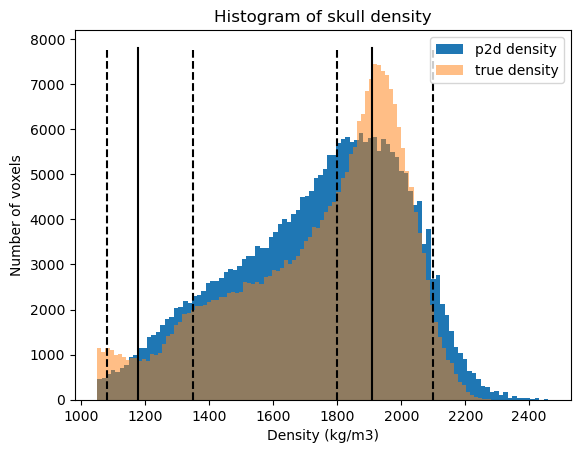

In [7]:
true_density_skull = true_density.copy()
true_density_skull[face_neck_sinuses] = 0
soft_tissue = (p2d_density_skull < 1050) | (true_density_skull < 1050)

true_density_skull_values = true_density_skull[~soft_tissue].flatten()
p2d_density_skull_values = p2d_density_skull[~soft_tissue].flatten()

plt.hist(p2d_density_skull_values, bins=100, label="p2d density")
plt.hist(true_density_skull_values, bins=100, alpha=0.5, label="true density")

plot_expected_bone_density(plt.ylim())

plt.title('Histogram of skull density')
plt.xlabel('Density (kg/m3)')
plt.ylabel('Number of voxels')
plt.legend(loc="upper right")
plt.show()

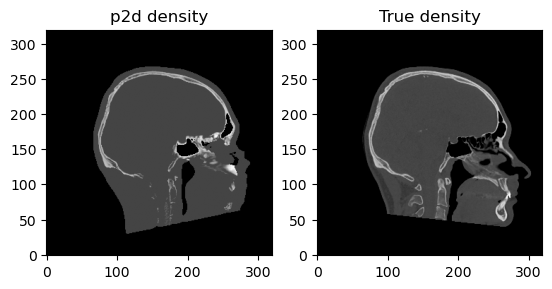

In [8]:
plt.subplot(1, 2, 1)
plt.title("p2d density")
plt.imshow(p2d_density[160, ...].T, cmap="gray", origin="lower", vmin=500, vmax=2500)
plt.subplot(1, 2, 2)
plt.title("True density")
plt.imshow(true_density[160, ...].T, cmap="gray", origin="lower", vmin=500, vmax=2500)
plt.show()

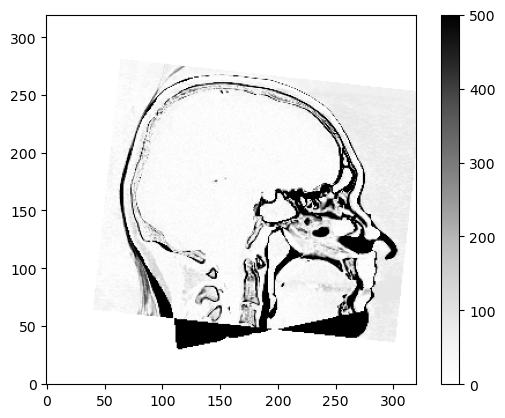

In [9]:
abs_diff = np.abs(p2d_density - true_density)
plt.imshow(abs_diff[160, ...].T, cmap="Greys", origin="lower", vmin=0, vmax=500)
plt.colorbar()
plt.show()

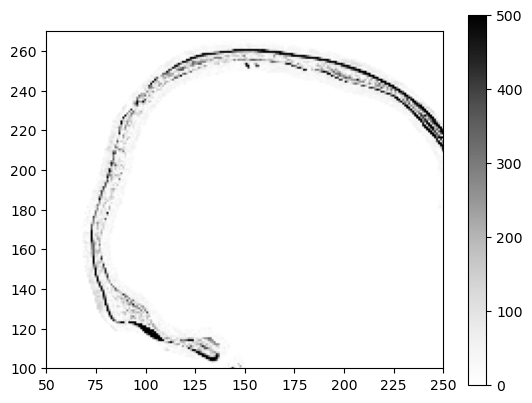

In [10]:
expanded_bone_mask = scipy.ndimage.binary_dilation(p2d_bone_mask, iterations=5)

abs_diff_bone = abs_diff.copy()
abs_diff_bone[expanded_bone_mask == 0] = 0
abs_diff_bone[face_neck_sinuses] = 0 

plt.imshow(abs_diff_bone[160, ...].T, cmap="Greys", origin="lower", vmin=0, vmax=500)
plt.xlim([50, 250])
plt.ylim([100, 270])
plt.colorbar()
plt.show()

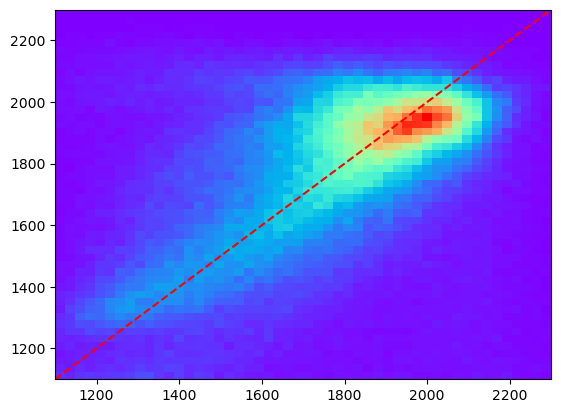

In [11]:
indices = (p2d_density > 1100) & (p2d_density < 2300) & (true_density > 1100) & (true_density < 2300) & (face_neck_sinuses == 0)
plt.hist2d(p2d_density[indices].flatten(), true_density[indices].flatten(), bins=50, cmap="rainbow")
plt.plot([1100, 2300], [1100, 2300], '--r')
plt.show()